# SLH-DSA (SPHINCS+) 강의 노트북
## 해시 기반 서명 (Stateless Hash-Based Digital Signature Algorithm, FIPS 205)

---

이 노트북은 **해시 기반 서명을 처음 배우는 사람**, 특히 수학이 익숙하지 않은 분을 위한 강의 자료입니다.
어려운 수식 대신 "일회용 도장", "봉인 스티커" 같은 일상의 비유로 설명합니다.

흐름은 이렇습니다: 이론 설명 → Lamport 일회용 서명(한 번 쓰고 버리는 도장) 만들기 →
Merkle 트리(도장 견본 정리함) 만들기 → 트리 구조 그림으로 보기 → "이 기술을 실무 어디에 쓰면 좋은가" 판단.
SLH-DSA(SPHINCS+)라는 서명 기술을 이루는 두 가지 핵심 부품을 **처음부터 직접 만들어 보며** 원리를 확인합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제를 분리·정리한 강의 자료입니다.
> 코드 셀과 출력은 원본 그대로 보존했으며, 재실행하려면 **0장(Setup)의 공통 설정 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. "되돌릴 수 없는 계산"인 해시 함수 하나만으로 전자서명을 만들 수 있다는 것(Lamport OTS)을 이해합니다.
2. "도장을 한 번밖에 못 쓴다"는 한계를 Merkle 트리라는 정리함으로 극복하는 방법을 압니다.
3. 잎(도장)이 아무리 많아져도, 확인 절차는 아주 조금씩만 늘어난다는 사실을 코드로 확인합니다.
4. SLH-DSA(SPHINCS+)가 어떤 부품(하이퍼트리·WOTS+·FORS)으로 조립되어 있고, 왜 "장부 없이(stateless)" 동작하는지 말로 설명할 수 있습니다.
5. 미국 표준(FIPS 205)이 된 SLH-DSA가 어떤 실무 환경에 어울리는지 판단할 수 있습니다.

> **선행 지식**: 거창한 수학은 필요 없습니다. "해시 함수는 원본을 되돌릴 수 없게 뭉개는 계산"이라는
> 감각과, 파이썬 코드를 대략 읽을 수 있는 정도면 충분합니다. 트리(나무 모양 자료구조)는 본문에서
> 그림과 함께 다시 설명합니다.

## 0. 준비 (Setup)

본격적인 실습 전에, 이 노트북 전체가 함께 쓰는 **공용 도구 상자**를 먼저 준비하는 셀입니다.
요리를 시작하기 전에 칼·도마·계량컵을 꺼내 놓는 것과 같습니다.

- `H`(SHA-256)와 `shake`: 이 강의의 주인공인 **해시 함수**들입니다. 어떤 데이터든 넣으면
  되돌릴 수 없는 짧은 지문(다이제스트)으로 바꿔 줍니다.
- `nbytes`: 데이터가 몇 바이트인지 재는 "저울"입니다.
- `timeit`: 계산에 걸린 시간을 재는 "스톱워치"입니다.
- `METRICS`: 나중에 다른 알고리즘과 비교할 수 있도록 측정값을 적어 두는 "기록장"입니다.
- 한글 폰트 자동 설정: 그래프의 한글이 네모(□□□)로 깨지지 않게 해 줍니다.

> 이 장의 모든 코드 셀은 아래 셀을 먼저 실행해야 동작합니다.

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. 해시 기반 서명 이론

### 1-0. 먼저, 해시 함수라는 부품부터

해시 함수는 **되돌릴 수 없는 용광로**입니다. 어떤 재료(데이터)를 넣어도 일정한 크기의
쇳덩이(해시값)가 나오지만, 녹인 결과만 보고 원재료가 무엇이었는지 알아낼 방법은 없습니다.
같은 재료를 넣으면 항상 같은 쇳덩이가 나오고, 재료가 한 글자만 달라져도 전혀 다른 쇳덩이가
나옵니다. 이 장에서 배우는 서명은 놀랍게도 **이 용광로 하나만으로** 만들어집니다.

### 1-1. Lamport 일회용 서명 (One-Time Signature, OTS)

OTS(One-Time Signature, 일회용 서명)는 이름 그대로 **한 번 쓰면 버리는 일회용 도장**입니다.
원리는 다음과 같습니다.

- **준비(키 생성)**: 서명할 메시지의 지문(해시)은 0과 1이 나열된 비트들입니다. 그 **비트
  하나마다** 비밀값을 2개(0이 나올 때 쓸 것, 1이 나올 때 쓸 것) 준비합니다. 그리고 각
  비밀값을 용광로(해시)에 넣은 결과들만 모아 **공개키**로 공개합니다.
- **서명**: 메시지 지문의 각 비트를 보고, 그 비트 값(0 또는 1)에 해당하는 쪽의 비밀값을
  **공개**합니다. 이 공개된 비밀값 묶음이 곧 서명입니다.
- **검증**: 받은 사람은 공개된 비밀값들을 다시 용광로에 넣어 보고, 미리 공개된 공개키의
  해당 항목과 일치하는지 확인합니다.

용광로는 되돌릴 수 없으므로, 공개키(녹인 결과)만 보고 비밀값(원재료)을 알아낼 수 없습니다.
그래서 서명을 위조할 수 없습니다.

> **주의**: 키 한 쌍은 **딱 한 번만** 사용해야 합니다. 서명 한 번에 비밀값의 절반이
> 공개되기 때문에, 여러 메시지에 재사용하면 공개된 비밀값이 점점 쌓여 결국 남이 내
> 도장을 위조할 수 있게 됩니다. "한 번 쓰고 버리는 일회용 도장"이라는 비유가 정확히
> 들어맞는 이유입니다.

### 1-2. Merkle 트리 — 일회용의 한계 극복

도장을 한 번 쓸 때마다 새 공개키를 온 세상에 다시 알려야 한다면 너무 불편합니다.
Merkle(머클) 트리는 **수많은 도장 견본을 하나의 봉인 스티커로 압축하는 정리함**입니다.

일회용 도장(OTS)의 공개키 여러 개를 정리함의 맨 아래 칸, 즉 **잎(leaf)** 으로 놓습니다.
잎들을 둘씩 짝지어 용광로에 넣고, 나온 결과를 또 둘씩 짝지어 넣고… 이 과정을 반복하면
맨 위에 단 하나의 값, **뿌리(root)** 가 남습니다. 세상에 공개하는 것은 이 뿌리 하나뿐입니다.

어떤 잎이 진짜인지 증명할 때는 잎 전체를 보여 줄 필요가 없습니다. 그 잎에서 뿌리까지
올라가는 동안 만나는 "옆자리 값"들만 있으면 됩니다. 이것을 **인증 경로**(authentication
path, 뿌리까지 가는 길에 필요한 형제 해시들의 목록)라고 부릅니다. 검증자는 이 옆자리
값들과 함께 계산을 따라 올라가 보고, 마지막에 뿌리와 일치하면 "이 잎은 진짜 정리함
소속"이라고 확신할 수 있습니다.

핵심은 효율입니다. 잎이 $N$개일 때 검증에 필요한 단계 수는 $\log_2 N$뿐입니다.

> **수식 풀이:** $N$은 정리함에 넣은 도장(잎)의 개수, $\log_2 N$은 "$N$이 되려면 2를 몇 번
> 곱해야 하는가"라는 뜻입니다. 예를 들어 잎이 8개면 $2 \times 2 \times 2 = 8$이므로 3단계,
> 잎이 100만 개가 넘어도 겨우 20단계 정도면 됩니다. 도장이 두 배로 늘어도 확인 절차는
> 딱 한 단계만 늘어나는 셈입니다.

### 1-3. SLH-DSA (SPHINCS+) — stateless 해시 서명

Merkle 트리 하나만으로는 문제가 하나 남습니다. 도장이 일회용이므로 "몇 번째 도장까지
썼는지" **장부를 꼬박꼬박 적어야** 합니다(이를 stateful, 즉 상태 관리가 필요하다고 합니다).
장부를 잃어버리거나 서버 두 대가 같은 장부를 놓고 엇갈리면 같은 도장을 두 번 쓰는 사고가
납니다. SPHINCS+는 다음 세 가지 부품으로 이 문제를 해결합니다.

- **하이퍼트리(hypertree)**: 정리함(Merkle 트리)을 한 개가 아니라 **여러 층으로 쌓아**,
  쓸 수 있는 도장의 총수를 천문학적으로 키웁니다. 각 층에서는 Lamport를 개선한
  **WOTS+**(Winternitz OTS, 비밀값을 더 알뜰하게 쓰는 개량형 일회용 도장)가 아래층
  정리함의 뿌리에 서명해 층과 층을 이어 붙입니다.
- **FORS**(Forest Of Random Subsets): 맨 아래층에서 실제 메시지 지문에 서명하는 부품으로,
  일회용이 아니라 **몇 번까지는 써도 되는(few-time)** 도장입니다.
- **무작위 잎 선택**: 서명할 때마다 어떤 도장을 쓸지 (의사)무작위로 고릅니다. 도장이
  천문학적으로 많으므로, 장부를 적지 않아도(**stateless**, 상태 없이 동작) 우연히 같은
  도장이 두 번 뽑힐 확률이 무시해도 될 만큼 작습니다. 덕분에 사실상 무제한으로 서명할 수
  있습니다.

이 구조가 2024년 8월 미국 표준 **FIPS 205**로 확정된 SLH-DSA입니다. 공개키는 32~64바이트로
매우 작지만, 서명은 수 KB~수십 KB로 큰 것이 특징입니다.

### 1-4. 이번 실습의 확인 기준

⑴ Lamport 도장으로 서명·검증이 성공하고, 변조된 메시지는 거부되는지,
⑵ Merkle 정리함이 여러 잎을 뿌리까지 인증하고, 가짜 잎은 거부하는지를 직접 실행해 확인합니다.

## 2. Lamport OTS — 밑바닥 구현과 검증

이제 "일회용 도장"을 직접 만들어 봅니다. 아래 셀은 Lamport 키 생성(메시지 지문의 비트
하나당 16바이트짜리 비밀값을 0용·1용 한 쌍씩, 총 256쌍 준비)·서명·검증 함수를 구현한 뒤,
실제 메시지에 서명하여 세 가지를 확인합니다.

⑴ 정상 메시지가 검증을 통과하는가, ⑵ 한 글자라도 고친 메시지는 거부되는가,
⑶ 공개키와 서명의 크기는 얼마나 되는가.

In [16]:
# ③ 밑바닥 구현 — Lamport OTS
def lamport_keygen(rng, nbits=256):
    sk = [(rng.bytes(16), rng.bytes(16)) for _ in range(nbits)]   # (0용, 1용) 비밀값 쌍
    pk = [(H(a), H(b)) for a, b in sk]                            # 각 해시가 공개키
    return sk, pk

def bits_of(digest):   # 메시지 해시(32B) → 256개 비트
    return [(byte >> i) & 1 for byte in digest for i in range(8)]

def lamport_sign(msg, sk):
    b = bits_of(H(msg))
    return [sk[i][bit] for i, bit in enumerate(b)]                # 해당 비트의 비밀값 공개

def lamport_verify(msg, sig, pk):
    b = bits_of(H(msg))
    return all(H(sig[i]) == pk[i][bit] for i, bit in enumerate(b))

# ④ 검증 — Lamport
rng = np.random.default_rng(101)
sk, pk = lamport_keygen(rng)
msg = b'I authorize payment of 500 USD'
sig = lamport_sign(msg, sk)
print('Lamport 정상 검증 :', lamport_verify(msg, sig, pk))
print('Lamport 변조 거부 :', not lamport_verify(msg + b' (tampered)', sig, pk))
print(f'공개키 ~{nbytes(pk)} B, 서명 ~{nbytes(sig)} B  (일회용!)')

Lamport 정상 검증 : True
Lamport 변조 거부 : True
공개키 ~16384 B, 서명 ~4096 B  (일회용!)


### 2-1. 결과 해석

- 정상 메시지는 검증을 통과하고(`True`), 한 글자라도 변조된 메시지는 거부됩니다(`True`).
  용광로의 성질 덕분에 지문이 조금만 달라져도 전혀 다른 결과가 나오기 때문입니다.
- 공개키는 약 **16384 B**입니다. 계산해 보면: 지문의 256개 비트 × 비트마다 2개(0용·1용) ×
  해시 결과 하나가 32 B = 16384 B. 일반적인 서명 공개키보다 꽤 큰 편입니다.
- 서명은 약 **4096 B**입니다: 256개 비트 × 공개하는 비밀값 하나가 16 B = 4096 B.

> 서명 한 번에 전체 비밀값의 절반이 공개되므로, 이 키 쌍은 **재사용할 수 없습니다**.
> 말 그대로 한 번 찍고 버려야 하는 도장입니다. 다음 절의 Merkle 트리가 바로 이 한계를
> 극복하는 장치입니다.

## 3. Merkle 트리 — 여러 OTS 공개키를 뿌리 하나로

이번에는 "도장 견본 정리함"을 만듭니다. 아래 셀은 세 가지 함수를 구현합니다.

- `merkle_root`: 잎(도장 공개키)들을 둘씩 짝지어 용광로에 넣으며 위로 합쳐,
  맨 위의 뿌리(봉인 스티커) 하나를 만듭니다.
- `merkle_path`: 특정 잎에서 뿌리까지 올라가는 길에 필요한 "옆자리 값"들(인증 경로)을 모읍니다.
- `merkle_verify`: 잎과 인증 경로만 가지고 뿌리를 다시 계산해 보고, 공개된 뿌리와
  일치하는지 대조합니다.

그다음 잎 8개짜리 정리함을 만들어, 5번 잎(`idx = 5`)이 경로만으로 인증되는지와
가짜 잎이 거부되는지를 확인합니다.

In [17]:
# ③ 밑바닥 구현 — Merkle 트리 (여러 OTS 공개키 → 하나의 root)
def merkle_root(leaves):
    layer = [H(x) for x in leaves]
    while len(layer) > 1:
        layer = [H(layer[i] + layer[i + 1]) for i in range(0, len(layer), 2)]
    return layer[0]

def merkle_path(leaves, idx):
    layer = [H(x) for x in leaves]; path = []
    while len(layer) > 1:
        path.append((layer[idx ^ 1], idx & 1))            # (형제 해시, 내가 오른쪽인가)
        layer = [H(layer[i] + layer[i + 1]) for i in range(0, len(layer), 2)]
        idx //= 2
    return path

def merkle_verify(leaf, path, root):
    cur = H(leaf)
    for sib, is_right in path:
        cur = H(sib + cur) if is_right else H(cur + sib)
    return cur == root

# ④ 검증 — Merkle (8개 잎)
rng = np.random.default_rng(202)
leaves = [rng.bytes(16) for _ in range(8)]
root = merkle_root(leaves)
idx = 5
path = merkle_path(leaves, idx)
print('Merkle 경로 인증  :', merkle_verify(leaves[idx], path, root))
print('Merkle 위조 잎 거부:', not merkle_verify(rng.bytes(16), path, root))
print(f'root(=공개키) {len(root)} B, 인증경로 {len(path)}단계  →  N개 잎을 log2(N)단계로 인증')
log_metric('SLH-DSA (SPHINCS+)', pk_bytes=len(root), sig_bytes=nbytes(sig) + nbytes(path),
           verify=1.0, forge_reject=1.0)

Merkle 경로 인증  : True
Merkle 위조 잎 거부: True
root(=공개키) 32 B, 인증경로 3단계  →  N개 잎을 log2(N)단계로 인증


### 3-1. 결과 해석

- 잎 #5는 인증 경로(옆자리 값들)만으로 뿌리에 연결됨이 증명되고(`True`),
  아무렇게나 만든 가짜 잎은 거부됩니다(`True`).
- 세상에 공개해야 하는 것은 **root 32 B** 하나뿐이고, 인증 경로는 **3단계**입니다.
  잎이 8개인데 8 = 2×2×2이므로 3단계면 충분한 것입니다.
- 잎을 아무리 늘려도 인증 단계는 "2를 몇 번 곱한 개수인가"만큼만 늘어납니다.
  잎이 두 배가 되어도 딱 한 단계 추가될 뿐입니다.
- 마지막 줄의 `log_metric`은 뒤의 종합 비교(Part IV)에서 사용할 공개키·서명 크기 지표를
  기록장에 적어 두는 부분입니다.

## 4. 시각화 — Merkle 트리 구조 (8잎 → 1뿌리)

정리함의 모양을 직접 눈으로 확인해 봅니다. 잎 8개가 둘씩 용광로에서 합쳐지며
뿌리 하나로 모이는 구조를 그립니다. 빨간색 노드가 잎 #5(L5)에서 뿌리까지 올라가는
**인증 경로**(검증할 때 실제로 지나가는 길)입니다.

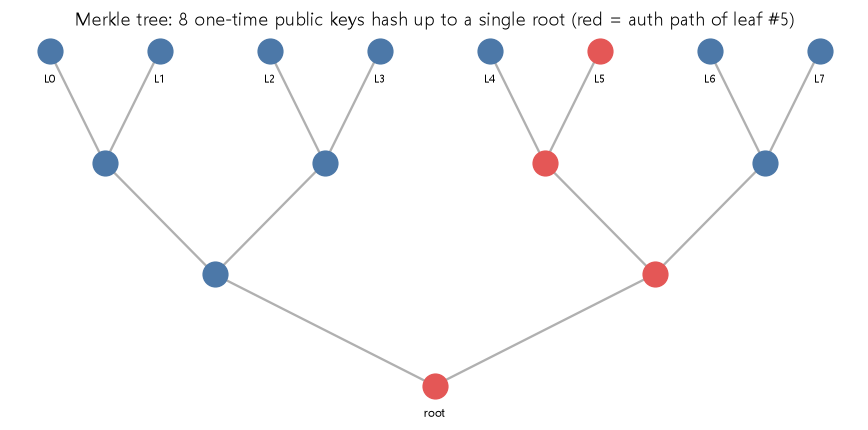

In [18]:
fig, ax = plt.subplots(figsize=(8, 4)); ax.axis('off')
levels = [8, 4, 2, 1]
pos = {}
for lv, count in enumerate(levels):
    y = len(levels) - 1 - lv
    for i in range(count):
        x = (i + 0.5) * (8 / count)
        pos[(lv, i)] = (x, y)
        on_path = False
        # 잎5의 경로 위 노드 강조
        idx5 = 5
        node_idx = idx5 >> lv
        on_path = (i == node_idx)
        color = '#E45756' if on_path else '#4C78A8'
        ax.scatter(x, y, s=260, color=color, zorder=3)
        lbl = f'L{i}' if lv == 0 else ('root' if lv == 3 else '')
        ax.text(x, y - 0.28, lbl, ha='center', fontsize=7)
for lv in range(len(levels) - 1):
    for i in range(levels[lv]):
        x0, y0 = pos[(lv, i)]; x1, y1 = pos[(lv + 1, i // 2)]
        ax.plot([x0, x1], [y0, y1], color='#B0B0B0', zorder=1)
ax.set_title('Merkle tree: 8 one-time public keys hash up to a single root (red = auth path of leaf #5)')
plt.tight_layout(); plt.show()

### 4-1. 그래프 해석

아래쪽 8개 노드(L0~L7)가 일회용 도장(OTS)의 공개키들이고, 위로 올라가며 둘씩 용광로에서
합쳐져 맨 위의 뿌리(root) 하나가 됩니다. 잎 #5는 **딱 3단계** 만에 뿌리에 도달하며
(8 = 2×2×2이므로 3단계), 검증에 필요한 것은 경로에서 만나는 옆자리 값 3개뿐입니다.

도장 8개의 목록을 통째로 공개하는 대신, "족보의 맨 위 조상"에 해당하는 뿌리(32바이트)
하나만 공개하면 됩니다. 어떤 도장이든 족보를 몇 단계만 거슬러 올라가면 진위를 증명할 수
있습니다. 일회용 도장의 "한 번뿐"이라는 한계를 이렇게 극복한 것이 SPHINCS+의 뼈대입니다.

> 잎을 수백만 개로 늘려도 검증 단계는 20단계 안팎으로만 늘어납니다(잎이 두 배가 될 때마다
> 한 단계씩). 해시 서명이 대규모 환경에서도 거뜬히 동작하는 이유입니다.

## 5. 표준화 현황과 실무 적용성

### 5-1. 실무 적용성

- **측정**: Lamport 도장의 서명·검증·변조 거부가 모두 정상 동작했고, Merkle 정리함이
  여러 잎을 몇 단계 만에 뿌리까지 인증했습니다. 이 두 부품이 SPHINCS+의 뼈대입니다.
- **표준**: 2024년 8월 미국 표준 **FIPS 205 (SLH-DSA)** 로 확정되었습니다. "해시 함수
  하나만 안전하면 된다"는, 믿어야 할 것이 가장 적은 **보수적인** 서명입니다. 그래서
  격자 기반 암호(또 다른 수학 문제에 기대는 방식)의 가정을 신뢰하기 어려운 최고보안
  환경에서 **백업/앵커**(최후의 안전장치)로 권장됩니다.
- **트레이드오프**: 서명이 크고(수 KB~수십 KB, 예를 들어 128비트 보안 파라미터에서
  7,856~17,088 B) 느립니다. 따라서 초당 수천 번 서명하는 곳보다 **드물게, 그러나 매우
  중요하게** 서명하는 곳 — 루트 인증서, 펌웨어 서명 루트, 장기 보존 문서 — 에 적합합니다.
- **핵심 장점**: 격자·정수론 같은 다른 수학적 가정이 훗날 깨지더라도 **해시 함수만
  버티면** 안전합니다. "믿어야 할 것을 최소로 줄인다"는 것이 이 방식의 가치입니다.

> **핵심**: SPHINCS+(SLH-DSA)는 해시만 믿는 가장 보수적인 서명입니다.
> 크고 느리지만, 가장 무너지기 어려운 백업입니다.

## 6. 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요. 정답보다 "왜 그렇게 되는지" 생각해 보는 것이
중요합니다.

1. **비밀값 길이**: `lamport_keygen`의 `rng.bytes(16)`을 `rng.bytes(32)`로 바꾸면
   서명 크기(현재 ~4096 B)가 어떻게 변할지 먼저 예측하고, 실행해서 확인해 보세요.
   공개키 크기(~16384 B)도 함께 변할까요? (힌트: 공개키는 비밀값 자체가 아니라
   비밀값을 용광로에 넣은 결과라는 점을 떠올려 보세요.)

2. **키 재사용의 위험**: 같은 `sk`(일회용 도장)로 서로 다른 메시지 2개에 서명한 뒤,
   두 서명에서 공개된 비밀값을 합쳐 보세요. 몇 개의 비트 위치에서 0용·1용 비밀값이
   **모두** 드러나는지 세어 보고, 이것이 왜 "남이 내 도장을 위조할 수 있는 상황"으로
   이어지는지 설명해 보세요.

3. **트리 키우기**: `leaves`를 8개에서 16개로 늘리면 인증 경로가 몇 단계가 될지
   예측하고, `len(merkle_path(leaves, idx))`로 확인하세요. 뿌리(root)의 크기(32 B)는
   변하나요? (힌트: 16 = 2×2×2×2)

4. **경로 순서의 중요성**: `merkle_verify`에 전달하는 `path`의 원소 순서나
   좌우 플래그(`is_right`)를 뒤집으면 검증이 실패함을 확인해 보세요. 옆자리 값만으로는
   부족하고 "내가 왼쪽이었는지 오른쪽이었는지"라는 정보가 왜 필요한지 설명해 보세요.

## 요약

- Lamport OTS는 **되돌릴 수 없는 용광로(해시)의 성질**만으로 서명을 만들지만,
  키 한 쌍은 한 번 쓰고 버려야 하는 일회용 도장이다.
- 실측 결과 Lamport 공개키 ~16384 B, 서명 ~4096 B로, 크기가 크다는 한계도 확인했다.
- Merkle 트리는 일회용 도장의 공개키 여러 개를 **뿌리 32 B 하나**(봉인 스티커)로 압축하고,
  몇 단계 안 되는 인증 경로로 각 잎을 증명한다 (8잎 실험에서 3단계, 잎이 두 배가 될 때마다
  한 단계씩만 증가).
- SPHINCS+(SLH-DSA)는 하이퍼트리(정리함 쌓기) + WOTS+(개량형 일회용 도장) +
  FORS(몇 번은 써도 되는 도장) + 무작위 잎 선택으로, 장부 없이(**stateless**) 사실상
  무제한 서명을 실현했다.
- 2024년 8월 **FIPS 205**로 확정되었으며, 크고 느리지만 믿어야 할 가정이 가장 적은
  **보수적 백업 서명**으로 쓰인다.

> 해시 기반 서명은 양자내성암호 가운데 가장 오래되고 단순한 보안 가정 위에 서 있습니다.
> 격자 기반 서명(ML-DSA)과 조합해 "격자가 무너져도 해시가 버틴다"는 이중 안전망을
> 구성하는 것이 실무에서 권장되는 방향입니다.